# Citation Validator — Evaluation Results

Benchmark ran 200 citations (80 VALID, 80 PARTIALLY_VALID, 40 HALLUCINATED) against the API.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

PLOTS_DIR = os.path.join(os.getcwd(), 'plots')
PREDICTIONS = os.path.join(os.getcwd(), 'results', 'predictions.csv')

df = pd.read_csv(PREDICTIONS)
print(f'Loaded {len(df)} predictions')
print(df['true_label'].value_counts().to_string())

Loaded 200 predictions
true_label
VALID              80
PARTIALLY_VALID    80
HALLUCINATED       40


## Classification Performance

| Metric | Value |
|--------|-------|
| Overall Accuracy | 0.6350 |
| Macro F1 | 0.6718 |
| VALID Precision | 0.6081 |
| VALID Recall | 0.5625 |
| PARTIALLY_VALID Precision | 0.5543 |
| PARTIALLY_VALID Recall | 0.6375 |
| HALLUCINATED Precision | 0.9118 |
| HALLUCINATED Recall | 0.7750 |

### Plot 1: Confusion Matrix

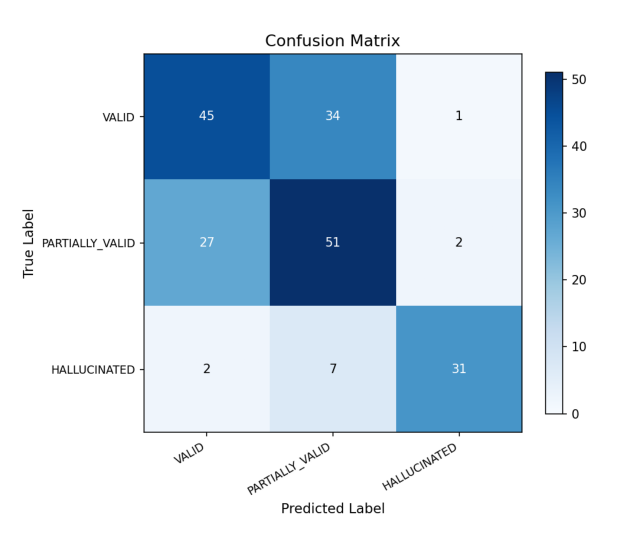

In [2]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'confusion_matrix.png'))
plt.figure(figsize=(8, 7))
plt.imshow(img)
plt.axis('off')
plt.show()

### Plot 2: Per-Class F1 Score

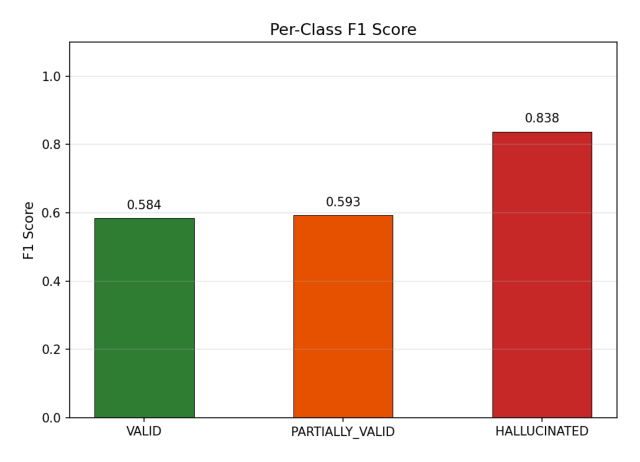

In [3]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'f1_barchart.png'))
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

### Plot 3: Confidence Score Distribution

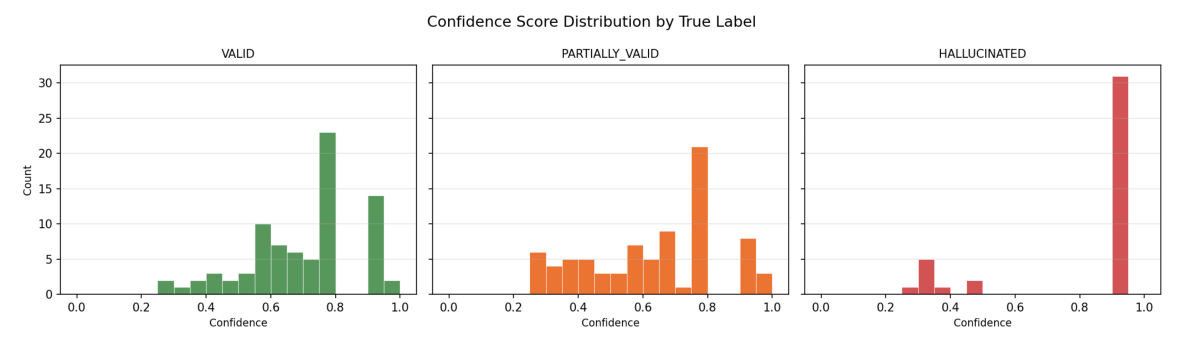

In [4]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'confidence_distribution.png'))
plt.figure(figsize=(15, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

### Plot 4: Misclassification by Corruption Type

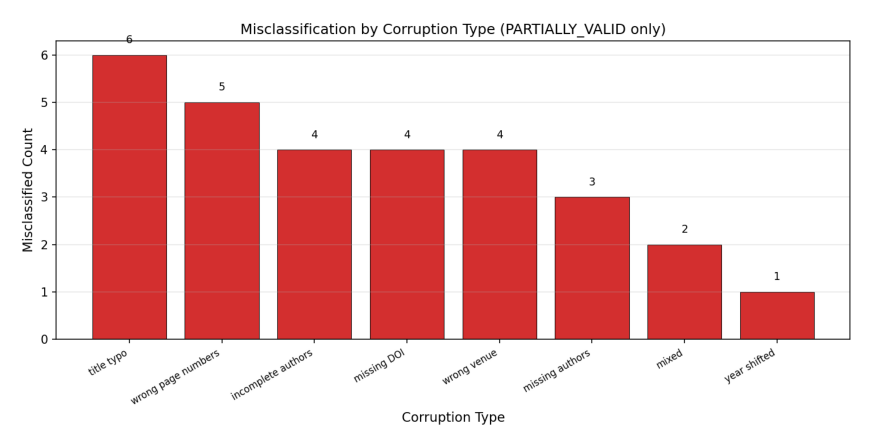

In [5]:
img = mpimg.imread(os.path.join(PLOTS_DIR, 'misclassification_by_corruption.png'))
plt.figure(figsize=(11, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

## Raw Predictions

In [7]:
df.head(20)

,citation_id,raw_citation,true_label,predicted_label,confidence,corruption_type,notes
0,27,"T. N. Kipf and M. Welling, ""Semi-Supervised Cl...",VALID,VALID,1.0000,NaN,NaN
1,46,"T. Mikolov, I. Sutskever, K. Chen, G. Corrado,...",VALID,VALID,0.7846,NaN,NaN
2,79,"I. Goodfellow, J. Pouget-Abadie, M. Mirza, B. ...",VALID,VALID,0.6316,NaN,NaN
3,154,"A. Radford et al., ""Learning to Generate Revie...",PARTIALLY_VALID,HALLUCINATED,0.9500,mixed,"Multiple fields corrupted (venue, year, authors)"
4,31,"C. Cortes and V. Vapnik, ""Support-Vector Netwo...",VALID,PARTIALLY_VALID,0.7500,NaN,NaN
5,175,"K. Simonyan, A. Vaswani, and J. Devlin, ""Deep ...",HALLUCINATED,HALLUCINATED,0.9500,NaN,NaN
6,134,"T. Brown, B. Mann, N. Ryder, M. Subbiah, J. D....",PARTIALLY_VALID,PARTIALLY_VALID,0.7000,wrong page numbers,Page numbers do not match the original
7,80,"D. Bahdanau, K. Cho, and Y. Bengio, ""Neural Ma...",VALID,VALID,0.9500,NaN,NaN
8,177,"P. Abbeel and G. Hinton, ""Variational Informat...",HALLUCINATED,HALLUCINATED,0.9500,NaN,NaN
9,82,"T. Mikolov, K. Chen, G. Corrado, and J. Dean, ...",PARTIALLY_VALID,PARTIALLY_VALID,0.7500,wrong venue,Venue changed to a different conference/journal


In [6]:
# Misclassified records
mis = df[df['true_label'] != df['predicted_label']]
print(f'Total misclassified: {len(mis)} out of {len(df)}')
mis[['citation_id', 'true_label', 'predicted_label', 'confidence', 'corruption_type']].head(30)

Total misclassified: 73 out of 200


,citation_id,true_label,predicted_label,confidence,corruption_type
3,154,PARTIALLY_VALID,HALLUCINATED,0.9500,mixed
4,31,VALID,PARTIALLY_VALID,0.7500,NaN
12,126,PARTIALLY_VALID,VALID,0.6978,title typo
16,131,PARTIALLY_VALID,VALID,0.6316,wrong page numbers
19,66,VALID,PARTIALLY_VALID,0.7500,NaN
20,41,VALID,PARTIALLY_VALID,0.7500,NaN
21,83,PARTIALLY_VALID,VALID,0.5105,wrong venue
25,132,PARTIALLY_VALID,VALID,0.5525,wrong page numbers
26,24,VALID,HALLUCINATED,0.9500,NaN
27,133,PARTIALLY_VALID,VALID,1.0000,wrong page numbers
